In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from datasets import load_dataset
import re
import random
from tensorflow import keras


In [ ]:
# Reproducibility: set global seeds
import os
import random
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


In [3]:
df = pd.read_csv("ranking_dataset.csv")

In [4]:
pairs = []
for i in range(len(df)):
  vals = []
  ranks = []
  for j in range(10):
    vals.append(df.iloc[i, j])
  for k in range(10, 20):
    ranks.append(df.iloc[i, k])
  pairs.append((vals, ranks))

print(pairs[0])

([np.int64(542), np.int64(67), np.int64(876), np.int64(414), np.int64(26), np.int64(335), np.int64(620), np.int64(924), np.int64(950), np.int64(113)], [np.int64(5), np.int64(1), np.int64(7), np.int64(4), np.int64(0), np.int64(3), np.int64(6), np.int64(8), np.int64(9), np.int64(2)])


In [5]:
train = pairs[:7000]
eval = pairs[7000:8500]
test = pairs[8500:]

In [6]:
def batches(pairs, batch_size):
    #random.shuffle(pairs)
    for i in range(0, len(pairs) - batch_size + 1, batch_size):

        batch = pairs[i: i + batch_size]

        inputs = []
        targets = []

        for i in batch:
            inputs.append(i[0])
            targets.append(i[1])

        yield tf.constant(inputs, dtype=tf.int32), tf.constant(targets, dtype=tf.int32)

In [7]:
%pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, d_model):
        super().__init__()

        pe = np.zeros((10, d_model))

        positions = np.arange(10).reshape(-1, 1)
        dims = np.arange(0, d_model, 2).reshape(1, -1)

        div_term = np.power(10000, dims/d_model)

        pe[:,0::2] = np.sin(positions/div_term)
        pe[:,1::2] = np.cos(positions/div_term)

        self.pe = tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]



In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model//num_heads

        self.W_Q = tf.keras.layers.Dense(d_model)
        self.W_K = tf.keras.layers.Dense(d_model)
        self.W_V = tf.keras.layers.Dense(d_model)

        self.W = tf.keras.layers.Dense(d_model)

    def split(self, x, batchsize):
        x = tf.reshape(x, (batchsize, -1, self.num_heads, self.d_k))

        return tf.transpose(x, perm=[0, 2, 1, 3])
        #(batch, num_heads, 10, d_k)

    def computation(self, Q, K, V):
        # Q @ K^T
        scores  = tf.matmul(Q, K, transpose_b=True)
        # divide by sqrt(d_k)
        scores = scores/tf.math.sqrt(tf.cast(self.d_k, tf.float32))
        weights = tf.nn.softmax(scores, axis=-1)
        output = tf.matmul(weights, V)
        return output, weights

    def call(self, x):
        batch_size = tf.shape(x)[0]
        Q = self.split(self.W_Q(x), batch_size)
        K = self.split(self.W_K(x), batch_size)
        V = self.split(self.W_V(x), batch_size)

        attn_out, weights = self.computation(Q, K, V)
        #(batch, heads, seq, d_k)
        #can use weights returned here to visualise attention later

        attn_out = tf.transpose(attn_out, perm=[0, 2, 1, 3])
        #(batch, seq, heads, d_k)

        attn_out = tf.reshape(attn_out, (batch_size, -1, self.num_heads * self.d_k))
        #(batch, seq, d_model)

        return self.W(attn_out)


class Encoder(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, f_dim):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ff1 = tf.keras.layers.Dense(f_dim, activation='relu')
        self.ff2 = tf.keras.layers.Dense(d_model)
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()

    def call(self, x):
        attn_out = self.attention(x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff2(self.ff1(x))
        x = self.norm2(x + ff_out) #residual connection

        return x


In [18]:
d_model = 128
num_heads = 8
f_dim = 256

batchsize = 100
EPOCHS = 25
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(axis = -1)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
print(train[:5])
print(batches(train[:5], 5))

[([np.int64(542), np.int64(67), np.int64(876), np.int64(414), np.int64(26), np.int64(335), np.int64(620), np.int64(924), np.int64(950), np.int64(113)], [np.int64(5), np.int64(1), np.int64(7), np.int64(4), np.int64(0), np.int64(3), np.int64(6), np.int64(8), np.int64(9), np.int64(2)]), ([np.int64(378), np.int64(14), np.int64(210), np.int64(954), np.int64(231), np.int64(572), np.int64(315), np.int64(295), np.int64(567), np.int64(706)], [np.int64(5), np.int64(0), np.int64(1), np.int64(9), np.int64(2), np.int64(7), np.int64(4), np.int64(3), np.int64(6), np.int64(8)]), ([np.int64(749), np.int64(876), np.int64(73), np.int64(111), np.int64(899), np.int64(213), np.int64(541), np.int64(769), np.int64(287), np.int64(219)], [np.int64(6), np.int64(8), np.int64(0), np.int64(1), np.int64(9), np.int64(2), np.int64(5), np.int64(7), np.int64(4), np.int64(3)]), ([np.int64(372), np.int64(880), np.int64(475), np.int64(329), np.int64(733), np.int64(564), np.int64(739), np.int64(376), np.int64(632), np.int64

In [ ]:
for Xtrain, ytrain in batches(train[:2], 2):
    print("X =", Xtrain)
    print("y =", ytrain)
    break

X = tf.Tensor(
[[542  67 876 414  26 335 620 924 950 113]
 [378  14 210 954 231 572 315 295 567 706]], shape=(2, 10), dtype=int32)
y = tf.Tensor(
[[5 1 7 4 0 3 6 8 9 2]
 [5 0 1 9 2 7 4 3 6 8]], shape=(2, 10), dtype=int32)


In [ ]:
inputs = tf.keras.Input(shape=(10,1))
emb = tf.keras.layers.Dense(d_model)(inputs)
emb = PositionalEncoding(d_model)(emb)
out = Encoder(d_model, num_heads, f_dim)(emb)
out = tf.keras.layers.Dropout(0.3)(out)
out = tf.keras.layers.Dense(10, activation = 'softmax')(out)
Transformer = tf.keras.Model(inputs, out)

#emb.shape

In [ ]:
import evaluate

losstrack = []
acctrack = []

# Checkpointing setup
ckpt = tf.train.Checkpoint(optimizer=optimizer, model=Transformer)
ckpt_manager = tf.train.CheckpointManager(ckpt, './checkpoints/encoder', max_to_keep=5)
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    print('Restored from', ckpt_manager.latest_checkpoint)

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    #training

    train_loss, steps = 0, 0
    for Xtrain, ytrain in batches(train, batchsize):
        with tf.GradientTape() as tape:
            predictions = Transformer(Xtrain, training=True)
            loss = loss_fn(ytrain, predictions)
        grads = tape.gradient(loss, Transformer.trainable_variables)
        optimizer.apply_gradients(zip(grads, Transformer.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    losstrack.append(train_loss/steps)

    #validation

    for Xval, yval in batches(eval, batchsize):
        predictions = Transformer(Xval, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = yval.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}%")

    # save checkpoint at end of epoch
    ckpt_manager.save()



Epoch 01/25  Loss: 1.2830  Val Acc: 47.53%
Epoch 02/25  Loss: 1.2185  Val Acc: 49.01%
Epoch 03/25  Loss: 1.1944  Val Acc: 42.57%
Epoch 04/25  Loss: 1.1937  Val Acc: 50.69%
Epoch 05/25  Loss: 1.2005  Val Acc: 48.01%
Epoch 06/25  Loss: 1.1934  Val Acc: 47.97%
Epoch 07/25  Loss: 1.1883  Val Acc: 50.15%
Epoch 08/25  Loss: 1.1558  Val Acc: 50.98%
Epoch 09/25  Loss: 1.2175  Val Acc: 50.12%
Epoch 10/25  Loss: 1.1704  Val Acc: 50.35%
Epoch 11/25  Loss: 1.1876  Val Acc: 50.99%
Epoch 12/25  Loss: 1.1740  Val Acc: 49.13%
Epoch 13/25  Loss: 1.1778  Val Acc: 50.80%
Epoch 14/25  Loss: 1.1553  Val Acc: 46.40%
Epoch 15/25  Loss: 1.1968  Val Acc: 50.72%
Epoch 16/25  Loss: 1.1534  Val Acc: 50.15%
Epoch 17/25  Loss: 1.1899  Val Acc: 51.07%
Epoch 18/25  Loss: 1.1542  Val Acc: 41.84%
Epoch 19/25  Loss: 1.2247  Val Acc: 49.24%
Epoch 20/25  Loss: 1.1756  Val Acc: 50.27%
Epoch 21/25  Loss: 1.1628  Val Acc: 50.19%
Epoch 22/25  Loss: 1.1854  Val Acc: 50.33%
Epoch 23/25  Loss: 1.1628  Val Acc: 50.61%
Epoch 24/25

In [ ]:
# Save final weights and optional full model export
import os
os.makedirs('./checkpoints/encoder', exist_ok=True)
Transformer.save_weights('./checkpoints/encoder/transformer_weights')

Transformer.save('./saved_models/transformer_full')


In [16]:
import matplotlib.pyplot as plt

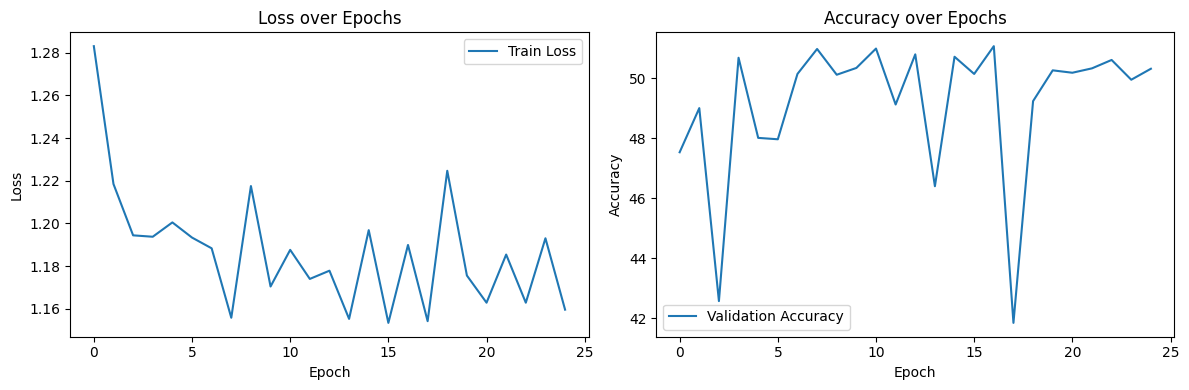

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
#testing

for Xtest, ytest in batches(test, batchsize):
        predictions = Transformer(Xtest, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = ytest.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

test_acc = accuracy_metric.compute()["accuracy"] * 100
print(f"\nTest Acc: {test_acc:.2f}%")


Test Acc: 50.30%


In [ ]:
for X,y  in batches(eval[:1],1):
  pred = Transformer(X, training=False)
  pred = tf.argmax(pred, axis=-1)

print(pred.numpy()[0])
print(y.numpy()[0])

print(np.mean(pred.numpy()[0] == y.numpy()[0]))

[3 4 1 8 1 3 6 9 2 0]
[5 6 2 8 1 4 7 9 3 0]
0.4


In [ ]:
accs = []

for X, y in batches(train[:100], 1):
    pred = Transformer(X, training=False)
    pred = tf.argmax(pred, axis=-1)

    accs.append(
        np.mean(pred.numpy()[0] == y.numpy()[0])
    )

print(np.mean(accs))
print(np.min(accs))
print(np.max(accs))

0.47300000000000003
0.2
0.8


In [ ]:
pred_probs = Transformer(X, training=False)

for i in range(10):
    print(pred_probs[0, i].numpy())

[1.5554073e-05 3.6152082e-03 4.1865893e-02 1.1494854e-01 2.0461588e-01
 2.8035063e-01 2.1726254e-01 1.1564110e-01 2.1683205e-02 1.4803641e-06]
[4.7286966e-01 4.0087575e-01 1.1203947e-01 1.0060288e-02 3.3026547e-03
 4.4972141e-04 2.6977455e-04 7.9367979e-05 5.2337702e-05 9.6512326e-07]
[2.8856283e-07 4.2031679e-05 1.0512250e-03 1.0540087e-03 5.0693867e-03
 1.6563140e-02 1.3061418e-01 2.3852696e-01 5.8173513e-01 2.5343591e-02]
[6.0358168e-05 2.2798724e-02 1.3002217e-01 2.1785516e-01 2.8795177e-01
 2.0402001e-01 9.6137665e-02 3.5772100e-02 5.3814300e-03 6.1487606e-07]
[8.8529950e-01 9.8981336e-02 1.4253100e-02 9.4562973e-04 3.8554121e-04
 5.7616759e-05 4.4809203e-05 1.5614396e-05 1.5954405e-05 1.0832039e-06]
[1.6100712e-04 6.9765702e-02 2.0263875e-01 2.8053737e-01 2.6460567e-01
 1.2013874e-01 4.5241684e-02 1.4782396e-02 2.1282127e-03 4.4347360e-07]
[7.5029820e-06 1.2414515e-03 1.8756196e-02 6.6319212e-02 1.4630228e-01
 2.6678976e-01 2.7549139e-01 1.7968598e-01 4.5403335e-02 2.9512012e-06]